In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [3]:
df.shape

(889, 14)

In [4]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]

y = df["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (889, 7)
y shape: (889,)


In [5]:
print(y.value_counts())

print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)

survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


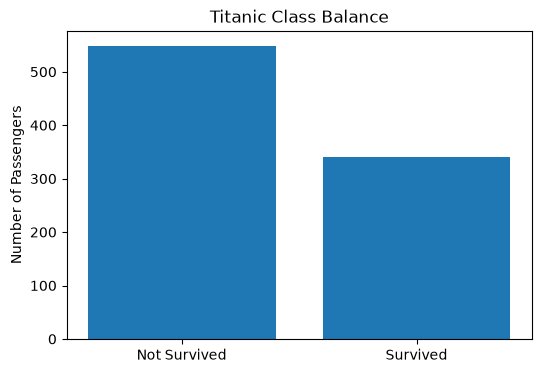

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))

plt.bar(
    ["Not Survived", "Survived"],
    [
        (y == 0).sum(),
        (y == 1).sum()
    ]
)

plt.title("Titanic Class Balance")
plt.ylabel("Number of Passengers")

plt.show()

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (711, 8)
Testing: (178, 8)


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "sex",
    "embarked"
]

X = df[features]

y = df["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())



X shape: (889, 7)
y shape: (889,)

X columns:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


numeric_features = [
    "pclass",
    "age",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]


In [47]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


In [48]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [59]:
model1 = LogisticRegression(max_iter=1000)

In [60]:

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model1)
    ]
)


In [61]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','age','sibsp',...,'fare','sex','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns tha

In [62]:
print(X_train.columns.tolist())

['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']


In [63]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [64]:
from sklearn.tree import DecisionTreeClassifier
model2= DecisionTreeClassifier(max_depth=5, random_state=42)

In [65]:
decision_tree_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        model2
    )
])

decision_tree_pipeline.fit(X_train,y_train)

tree_pred = decision_tree_pipeline.predict(X_test)
tree_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [66]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(n_estimators=100, random_state=42)

In [67]:
random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        model3
    )
])

random_forest_pipeline.fit(X_train,y_train)

rf_pred = random_forest_pipeline.predict(X_test)
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    print("\n==============================")
    print(name)
    print("==============================")

    print("Confusion Matrix:")
    print(cm)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("AUC      :", auc)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

In [71]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred,
        y_proba
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred,
        tree_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)


Logistic Regression
Confusion Matrix:
[[91 19]
 [21 47]]
Accuracy : 0.7752808988764045
Precision: 0.7121212121212122
Recall   : 0.6911764705882353
F1 Score : 0.7014925373134329
AUC      : 0.8517379679144386

Decision Tree
Confusion Matrix:
[[99 11]
 [30 38]]
Accuracy : 0.7696629213483146
Precision: 0.7755102040816326
Recall   : 0.5588235294117647
F1 Score : 0.6495726495726496
AUC      : 0.8411096256684492

Random Forest
Confusion Matrix:
[[100  10]
 [ 19  49]]
Accuracy : 0.8370786516853933
Precision: 0.8305084745762712
Recall   : 0.7205882352941176
F1 Score : 0.7716535433070866
AUC      : 0.8346256684491979


In [72]:
classification_results = pd.DataFrame(results)

print(classification_results)

                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.775281   0.712121  0.691176  0.701493  0.851738
1        Decision Tree  0.769663   0.775510  0.558824  0.649573  0.841110
2        Random Forest  0.837079   0.830508  0.720588  0.771654  0.834626


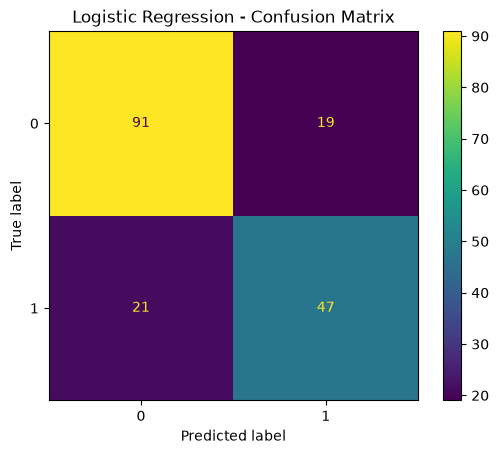

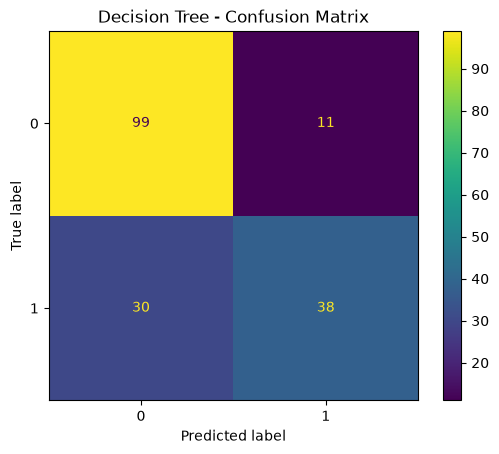

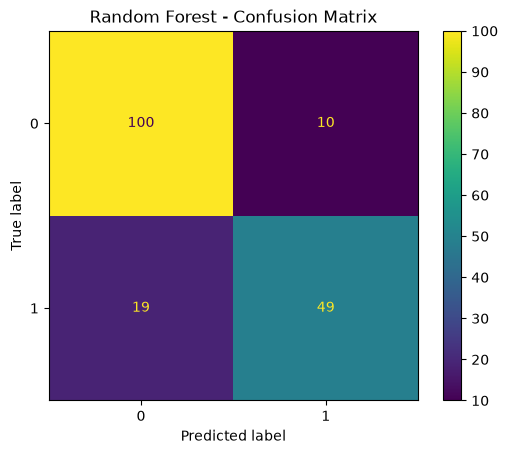

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": (
        pipeline,
        y_pred
    ),
    "Decision Tree": (
        decision_tree_pipeline,
        tree_pred
    ),
    "Random Forest": (
        random_forest_pipeline,
        rf_pred
    )
}

for name, (model, predictions) in models.items():

    ConfusionMatrixDisplay.from_predictions( y_test,predictions)

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [74]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_proba
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob
)

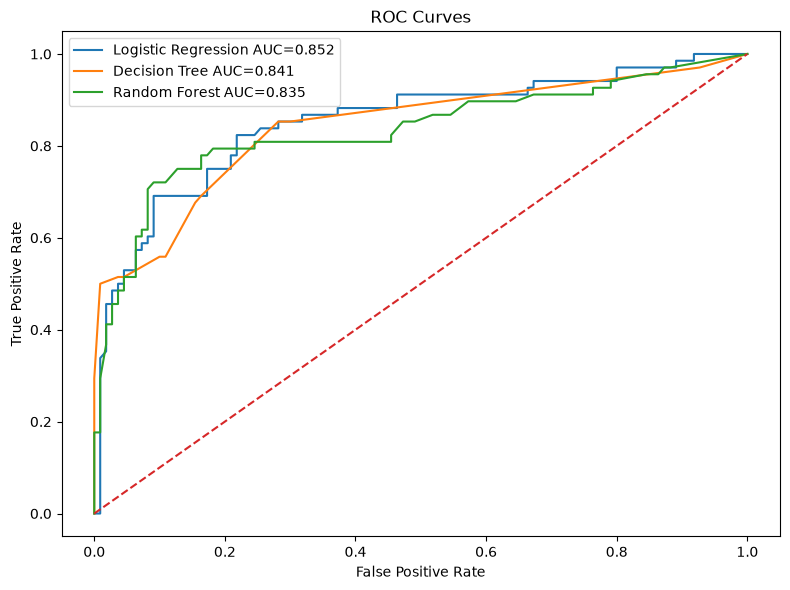

In [75]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression AUC={roc_auc_score(y_test, y_proba):.3f}"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree AUC={roc_auc_score(y_test, tree_prob):.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC={roc_auc_score(y_test, rf_prob):.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.tight_layout()

plt.savefig("charts/roc_curves.png")

plt.show()

In [78]:
tree_preprocessor = (decision_tree_pipeline.named_steps["preprocessor"])
tree_preprocessor
tree_model = (decision_tree_pipeline.named_steps["model"])
tree_model

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [80]:
feature_names = (tree_preprocessor.get_feature_names_out())

print(feature_names)

['num__pclass' 'num__age' 'num__fare' 'cat__sex_female' 'cat__sex_male'
 'cat__embarked_C' 'cat__embarked_Q' 'cat__embarked_S']


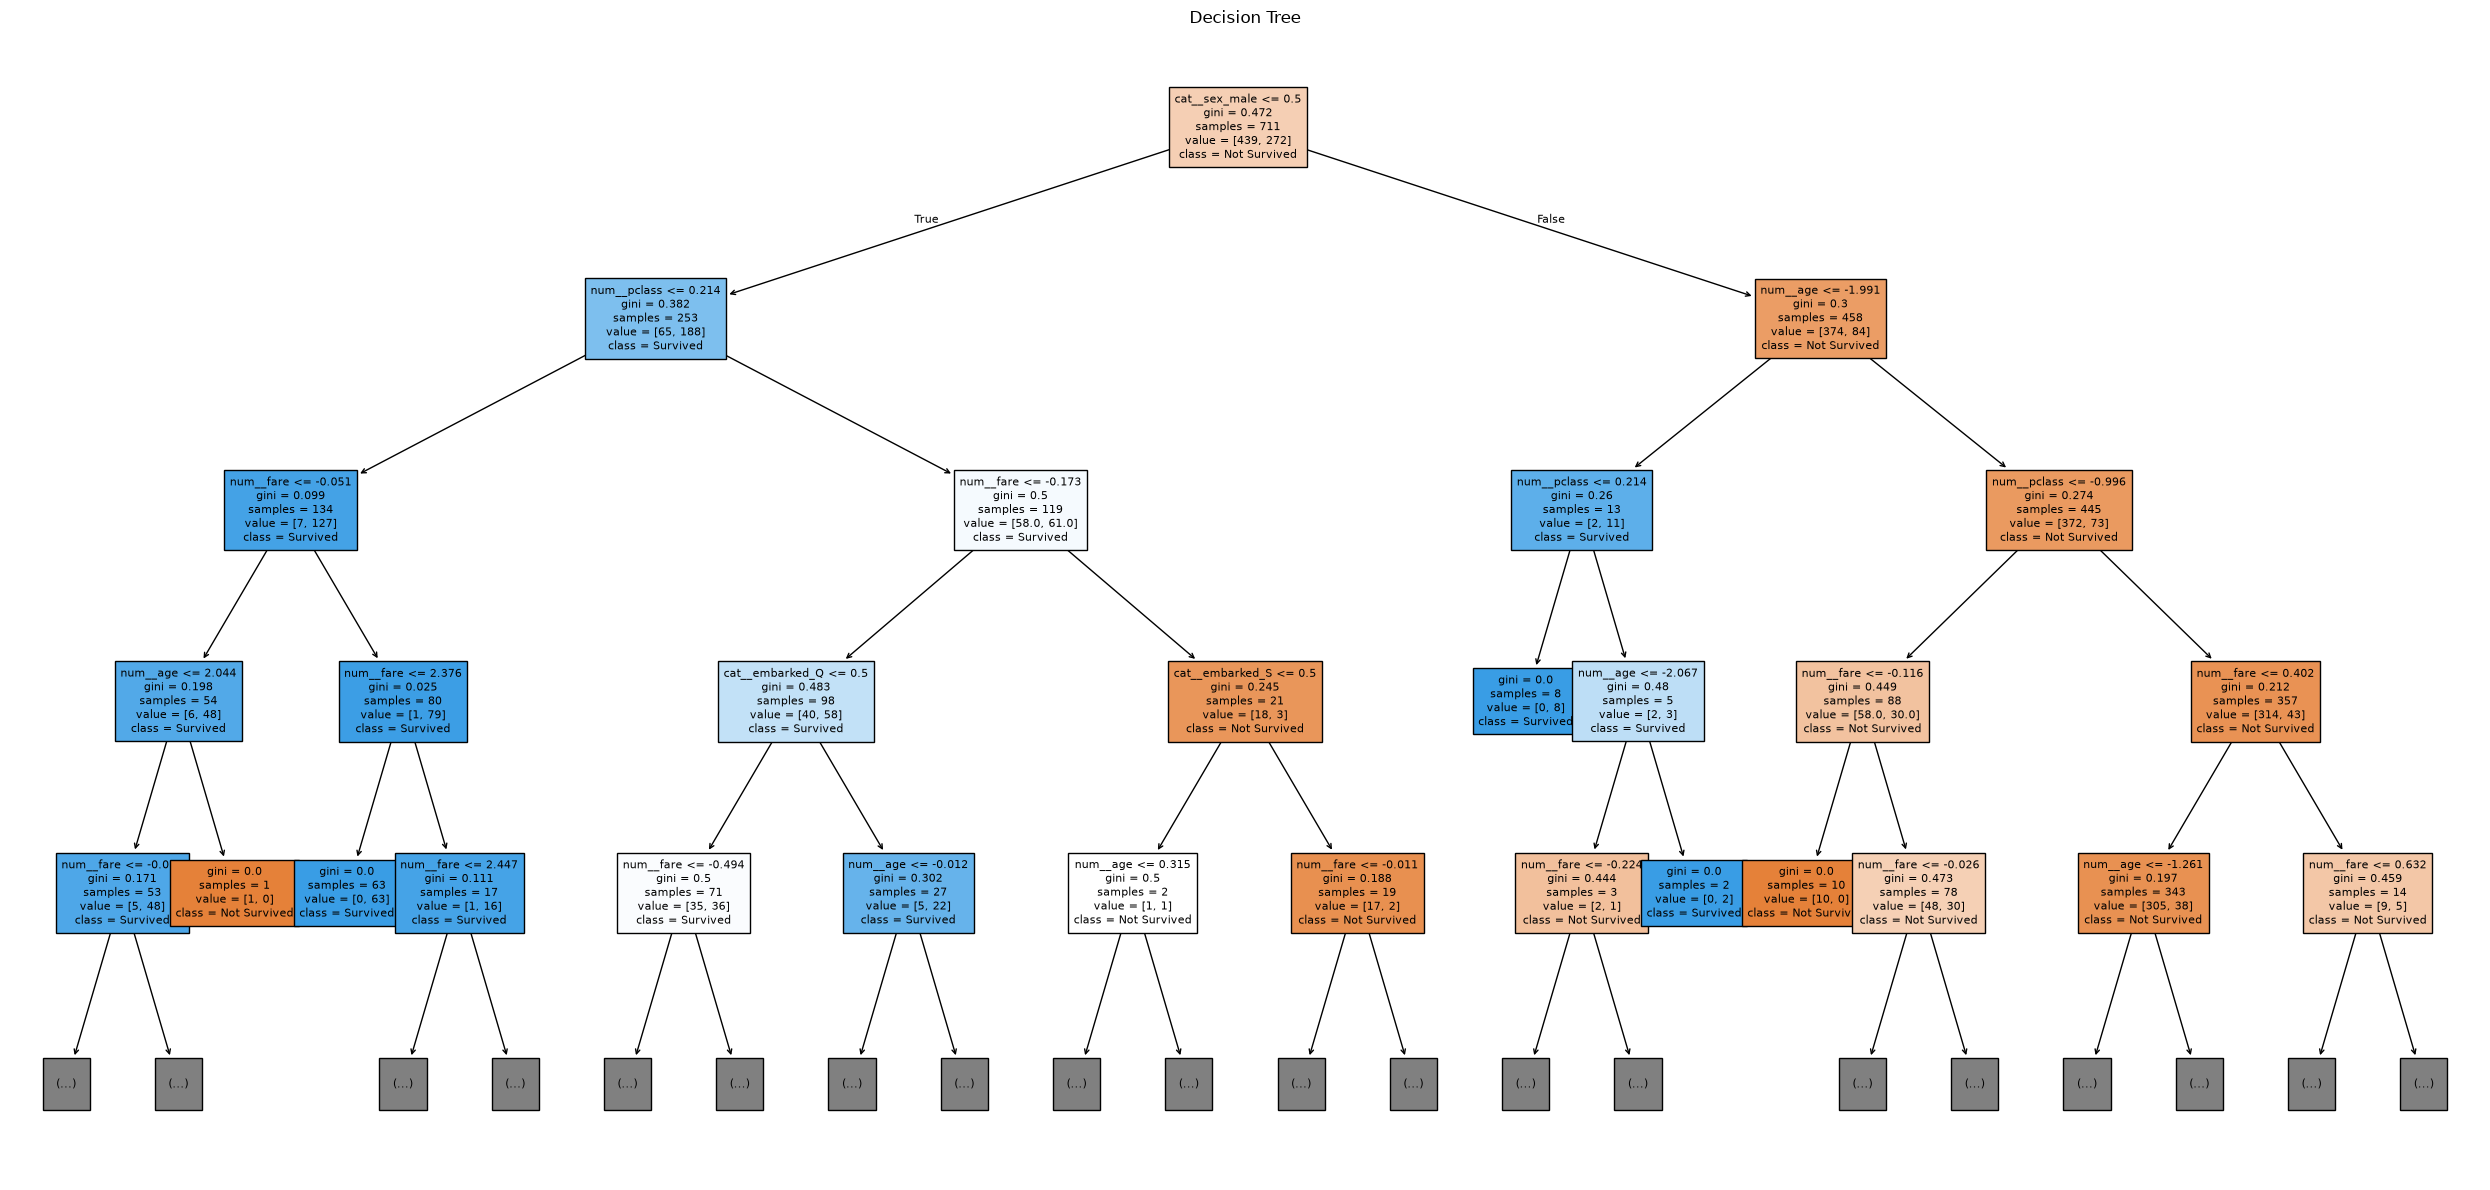

In [81]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    max_depth=4,
    fontsize=8
)

plt.title("Decision Tree")

plt.tight_layout()

plt.savefig("charts/decision_tree.png")

plt.show()

In [86]:
print("Class balance:")
print(y_train.value_counts())

Class balance:
survived
0    439
1    272
Name: count, dtype: int64


In [96]:
model11 =  LogisticRegression(max_iter=1000)

In [97]:
baseline_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
         model11
    )
])

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(X_test)
baseline_pred 


array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [98]:
model12 =  LogisticRegression(max_iter=1000,class_weight="balanced")

In [99]:
balanced_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
         model12
    )
])

balanced_model.fit(
    X_train,
    y_train
)

balanced_pred = balanced_model.predict(X_test)

balanced_pred

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [95]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [102]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
smote_model = ImbPipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

smote_model.fit(
    X_train,
    y_train
)

smote_pred = smote_model.predict(X_test)
smote_pred

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [103]:
imbalance_results = []

for name, predictions in [
    ("Baseline", baseline_pred),
    ("Class Weight Balanced", balanced_pred),
    ("SMOTE", smote_pred)
]:

    imbalance_results.append({
        "Method": name,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        )
    })

imbalance_table = pd.DataFrame(
    imbalance_results
)

print(imbalance_table)

                  Method  Precision    Recall        F1
0               Baseline   0.712121  0.691176  0.701493
1  Class Weight Balanced   0.696203  0.808824  0.748299
2                  SMOTE   0.693333  0.764706  0.727273


In [104]:
param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}

In [107]:
rf_for_grid = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42,
            oob_score=True,
            bootstrap=True
        )
    )
])

In [108]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [109]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best CV Score:
0.7559806046265674


In [110]:
best_rf_model = (grid_search.best_estimator_.named_steps["model"])
print("OOB Score:")
print(best_rf_model.oob_score_)

OOB Score:
0.8185654008438819


In [111]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked",
    "survived"
]

X_reg = df[regression_features]

y_reg = df["fare"]

In [112]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [113]:
reg_numeric = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "survived"
]

reg_categorical = [
    "sex",
    "embarked"
]

In [114]:
reg_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

reg_categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [115]:
reg_preprocessor = ColumnTransformer([
    (
        "numeric",
        reg_numeric_pipeline,
        reg_numeric
    ),
    (
        "categorical",
        reg_categorical_pipeline,
        reg_categorical
    )
])

In [116]:
from sklearn.linear_model import LinearRegression

regression_model = Pipeline([
    (
        "preprocessor",
        reg_preprocessor
    ),
    (
        "model",
        LinearRegression()
    )
])

regression_model.fit(
    X_reg_train,
    y_reg_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','embarked','survived']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

In [118]:
fare_pred = regression_model.predict(X_reg_test)
fare_pred

array([ -3.06485684,  95.97288034,  28.27568788,  28.68309409,
        89.33655929,  -1.13408757,  29.21812543,  -2.31581297,
       100.54790323,  84.27921856,  30.18118183,   8.93200056,
        -5.52600098,  21.63107633,  -3.17186311,  -3.06485684,
        82.98685285,  15.20876782,  64.08145355,  -3.06485684,
        54.84436179,  77.24305153,   6.46050052,  79.13269475,
        -3.06485684,  77.84861954,  46.31468115,  41.75426913,
        60.85907009,  29.11111916,  62.68283309,   9.79230566,
        -3.06485684,  78.27664461,  45.95314431,  66.10430967,
        46.47048535,  80.20741388,  15.20876782,  -3.06485684,
        26.97099382,   7.00123129,  29.43213796,  -2.85084431,
        62.04079549,  79.67238254,  49.87963358,  -2.63683177,
        28.25506902,  93.16253831,  58.55166476,  10.75536206,
        -2.42281924,  33.39330233,  46.88618207,  35.22069938,
        27.94987972,  -4.24192578,  -1.78078164,  28.68309409,
        50.35282255,  17.70365758,  87.27732653,  -1.78

In [120]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_reg_test,fare_pred)

rmse = np.sqrt(mean_squared_error(y_reg_test,fare_pred))

r2 = r2_score(y_reg_test,fare_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 21.098604259640457
RMSE: 41.70210467903215
R²  : 0.348162572160543


In [121]:
n = len(y_reg_test)

p = (regression_model.named_steps["preprocessor"].transform(X_reg_test).shape[1])

adjusted_r2 = (1 -((1 - r2) * (n - 1) / (n - p - 1)))

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.30913039085279115


In [123]:
residuals = y_reg_test - fare_pred
residuals 


280    10.919057
434    24.027120
39    -17.033988
417   -15.683094
584    -9.686559
         ...    
432     9.012788
806     6.233021
25    -31.163638
84     -4.535536
10     -5.395571
Name: fare, Length: 178, dtype: float64

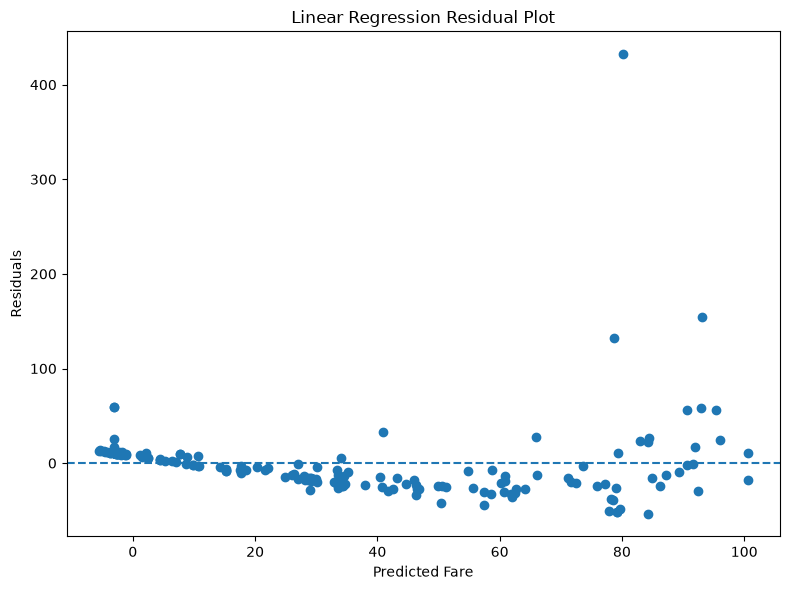

In [124]:
plt.figure(figsize=(8, 6))

plt.scatter(fare_pred,residuals)

plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.title("Linear Regression Residual Plot")

plt.tight_layout()

plt.savefig("charts/residual_plot.png")

plt.show()

In [125]:
classification_results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.775281,0.712121,0.691176,0.701493,0.851738
1,Decision Tree,0.769663,0.775510,0.558824,0.649573,0.841110
2,Random Forest,0.837079,0.830508,0.720588,0.771654,0.834626


In [126]:
regression_results = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]
})

print(regression_results)

    Regression Model        MAE       RMSE        R2  Adjusted R2
0  Linear Regression  21.098604  41.702105  0.348163      0.30913


In [127]:
best_model_row = classification_results.loc[classification_results["F1"].idxmax()]

print("Best classifier based on F1:")
print(best_model_row)

Best classifier based on F1:
Model        Random Forest
Accuracy          0.837079
Precision         0.830508
Recall            0.720588
F1                0.771654
AUC               0.834626
Name: 2, dtype: object


In [128]:
print(classification_results.sort_values("AUC", ascending=False))

                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.775281   0.712121  0.691176  0.701493  0.851738
1        Decision Tree  0.769663   0.775510  0.558824  0.649573  0.841110
2        Random Forest  0.837079   0.830508  0.720588  0.771654  0.834626


In [129]:
import joblib

full_pipeline = grid_search.best_estimator_

joblib.dump(full_pipeline,"best_titanic_pipeline.joblib")

print("Complete pipeline saved successfully.")

Complete pipeline saved successfully.


In [130]:
loaded_pipeline = joblib.load("best_titanic_pipeline.joblib")

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [131]:
new_passenger = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [10.5],
    "embarked": ["S"]
})

In [133]:
prediction = loaded_pipeline.predict(new_passenger)

probability = loaded_pipeline.predict_proba(new_passenger)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.90908332 0.09091668]]
